# Gensim — Ejemplos prácticos (con y sin Internet)

Cuaderno didáctico con ejemplos de uso de **Gensim**. Incluye dos modos:
- **Modo Online**: descarga embeddings preentrenados con `gensim.downloader`.
- **Modo Offline**: usa embeddings toy y/o entrena Word2Vec/Doc2Vec sobre un corpus pequeño.

> Recomendación: si te falla SciPy/Gensim en Windows, reinstala `numpy`, `scipy` y `gensim` vía conda-forge.

## 0) Versiones

In [ ]:
import sys
vers = {}
try:
    import gensim
    vers['gensim'] = gensim.__version__
except Exception as e:
    vers['gensim'] = f'No disponible ({e})'
try:
    import numpy as np
    vers['numpy'] = np.__version__
except Exception as e:
    vers['numpy'] = f'No disponible ({e})'
try:
    import scipy
    vers['scipy'] = scipy.__version__
except Exception as e:
    vers['scipy'] = f'No disponible ({e})'
print(vers)


{'gensim': "No disponible (No module named 'gensim')", 'numpy': '2.0.2', 'scipy': '1.16.3'}


In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 80.3 MB/s eta 0:00:00


## 1) Cargar embeddings preentrenados (Online) con fallback Offline

In [ ]:
import numpy as np
kv = None
loaded_online = False
try:
    import gensim.downloader as api
    kv = api.load('glove-wiki-gigaword-100')  # 100D
    loaded_online = True
    print('Embeddings online cargados:', len(kv), 'dim=', kv.vector_size)
except Exception as e:
    print('No se pudieron cargar embeddings online:', e)
    print('Usando modo Offline (toy embeddings).')
    toy_vectors = {
        'king':  np.array([0.72, 0.51, 0.11, 0.33, 0.27]),
        'queen': np.array([0.70, 0.50, 0.12, 0.30, 0.29]),
        'man':   np.array([0.65, 0.49, 0.08, 0.28, 0.25]),
        'woman': np.array([0.66, 0.48, 0.10, 0.26, 0.28]),
        'paris': np.array([0.10, 0.85, 0.22, 0.61, 0.77]),
        'france':np.array([0.12, 0.86, 0.20, 0.60, 0.79]),
        'madrid':np.array([0.09, 0.80, 0.25, 0.58, 0.73]),
        'spain': np.array([0.11, 0.82, 0.23, 0.59, 0.75]),
        'dog':   np.array([0.30, 0.10, 0.79, 0.66, 0.18]),
        'cat':   np.array([0.31, 0.12, 0.77, 0.65, 0.20]),
        'chair': np.array([0.05, 0.06, 0.40, 0.10, 0.03]),
        'table': np.array([0.06, 0.05, 0.42, 0.11, 0.04]),
    }
    class ToyKeyedVectors:
        def __init__(self, data):
            self.data = data
            self.index_to_key = list(data.keys())
            self.key_to_index = {k:i for i,k in enumerate(self.index_to_key)}
            self.vector_size = len(next(iter(data.values())))
        def __contains__(self, key):
            return key in self.data
        def get_vector(self, key):
            return self.data[key]
        def __getitem__(self, key):
            return self.data[key]
        def similarity(self, w1, w2):
            v1, v2 = self[w1], self[w2]
            num = float(np.dot(v1, v2))
            den = float(np.linalg.norm(v1) * np.linalg.norm(v2)) + 1e-12
            return num/den
        def most_similar(self, positive=None, negative=None, topn=5):
            pos = positive or []
            neg = negative or []
            target = np.zeros(self.vector_size, dtype=float)
            for w in pos:
                target += self[w]
            for w in neg:
                target -= self[w]
            sims = []
            posneg = set(pos + neg)
            for k, v in self.data.items():
                if k in posneg:
                    continue
                num = float(np.dot(target, v))
                den = float(np.linalg.norm(target) * np.linalg.norm(v)) + 1e-12
                sims.append((k, num/den))
            sims.sort(key=lambda x: x[1], reverse=True)
            return sims[:topn]
        def __len__(self):
            return len(self.data)
    kv = ToyKeyedVectors(toy_vectors)
    print('Embeddings toy cargados:', len(kv), 'dim=', kv.vector_size)


[==================================================] 100.0% 128.1/128.1MB downloaded
Embeddings online cargados: 400000 dim= 100


## 2) Similitud entre palabras

In [ ]:
def try_similarity(a, b):
    try:
        if hasattr(kv, 'similarity'):
            return kv.similarity(a, b)
        import numpy as np
        v1, v2 = kv[a], kv[b]
        return float(np.dot(v1, v2) / (np.linalg.norm(v1)*np.linalg.norm(v2) + 1e-12))
    except Exception as e:
        return f'Error: {e}'
pares = [("king","queen"),("king","table"),("paris","france"),("madrid","spain")]
for a,b in pares:
    sim = try_similarity(a,b)
    print(f"{a} ~ {b} -> {sim}")


king ~ queen -> 0.7507690787315369
king ~ table -> 0.2966259717941284
paris ~ france -> 0.7481586337089539
madrid ~ spain -> 0.7078268527984619


In [ ]:
try_similarity('paris', 'spain')

np.float32(0.4942618)

In [ ]:
try_similarity('madrid', 'france')

np.float32(0.53791696)

## 3) Palabras más similares

In [ ]:
query = 'humano'
try:
    print(kv.most_similar(query, topn=100))
except Exception as e:
    print('most_similar no disponible en este modo:', e)


[('distinto', 0.7145511507987976), ('clon', 0.6833738684654236), ('enemigo', 0.6567607522010803), ('esencial', 0.6535075306892395), ('fisico', 0.6445111036300659), ('argumento', 0.6418243050575256), ('clima', 0.6403559446334839), ('observador', 0.6365772485733032), ('appliquée', 0.6363480687141418), ('paisaje', 0.6340879201889038), ('ambiente', 0.6281339526176453), ('minorista', 0.627123236656189), ('transparente', 0.6258032917976379), ('maravilloso', 0.624050498008728), ('privado', 0.6232964396476746), ('divertido', 0.6229529976844788), ('cuento', 0.6222193241119385), ('judio', 0.6208945512771606), ('extranjero', 0.6198216080665588), ('barato', 0.6177724003791809), ('conservador', 0.6175011396408081), ('estudiante', 0.616279661655426), ('sacrificio', 0.61606764793396), ('reloj', 0.6154531836509705), ('caracoles', 0.6148296594619751), ('integrado', 0.6133357286453247), ('fumar', 0.611868143081665), ('escenario', 0.6112706065177917), ('diferente', 0.6109649538993835), ('enfoque', 0.6103

## 4) Analogías semánticas

In [ ]:
def analogia(a, b, c, topn=5):
    if hasattr(kv, 'most_similar'):
        return kv.most_similar(positive=[b, c], negative=[a], topn=topn)
    raise RuntimeError('Función no disponible en este modo')
try:
    print('man:king::woman: ?', analogia('man','king','woman', topn=5))
    print('france:paris::spain: ?', analogia('france','paris','spain', topn=5))
except Exception as e:
    print('Analogías no disponibles:', e)


man:king::woman: ? [('queen', 0.7698540687561035), ('monarch', 0.6843381524085999), ('throne', 0.6755736470222473), ('daughter', 0.6594556570053101), ('princess', 0.6520534157752991)]
france:paris::spain: ? [('madrid', 0.8061118125915527), ('aires', 0.7141226530075073), ('buenos', 0.6974525451660156), ('prohertrib', 0.6854169964790344), ('rome', 0.6848843693733215)]


## 5) Visualización 2D (PCA)

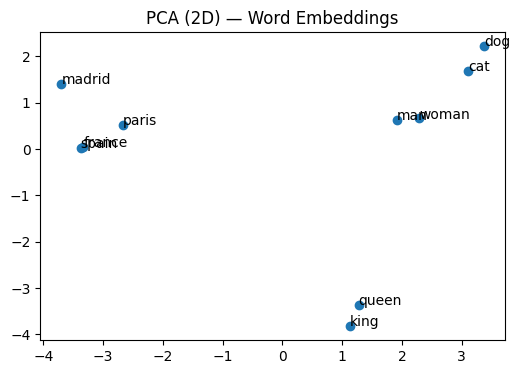

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
palabras = ['king','queen','man','woman','paris','france','madrid','spain','dog','cat']
X = np.array([kv[w] for w in palabras], dtype=float)
pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X)
plt.figure(figsize=(6,4))
plt.scatter(X2[:,0], X2[:,1])
for i,w in enumerate(palabras):
    plt.annotate(w, (X2[i,0], X2[i,1]))
plt.title('PCA (2D) — Word Embeddings')
plt.show()


## 6) Entrenar tus propios embeddings (Word2Vec)

In [ ]:
from gensim.models import Word2Vec
sentences = [
    ['gato','come','pescado'],
    ['perro','ladra'],
    ['gato','y','perro','son','animales'],
    ['madrid','es','capital','de','españa'],
    ['paris','es','capital','de','francia']
]
w2v = Word2Vec(sentences, vector_size=50, window=3, min_count=1, workers=2, seed=42)
print('Dim:', w2v.wv.vector_size, 'Vocab:', len(w2v.wv))
print('Vec(gato)[:5]:', w2v.wv['gato'][:5])
print('Más similares a gato:', w2v.wv.most_similar('gato', topn=5))


Dim: 50 Vocab: 15
Vec(gato)[:5]: [-0.00534777  0.01634472 -0.0002004   0.00798712 -0.0017021 ]
Más similares a gato: [('y', 0.1947450488805771), ('paris', 0.1271558701992035), ('es', 0.10911133885383606), ('come', 0.10464680939912796), ('son', 0.04583301767706871)]


## 7) Similitud de documentos (Doc2Vec)

In [ ]:
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
docs = [
    TaggedDocument(words=['gato','duerme'], tags=['d1']),
    TaggedDocument(words=['perro','ladra'], tags=['d2']),
    TaggedDocument(words=['madrid','capital'], tags=['d3'])
]
d2v = Doc2Vec(docs, vector_size=40, window=2, min_count=1, workers=2, seed=42)
v1 = d2v.dv['d1']; v2 = d2v.dv['d2']
import numpy as np
cos = float(np.dot(v1,v2)/(np.linalg.norm(v1)*np.linalg.norm(v2)+1e-12))
print('cos(d1,d2)=', round(cos,3))


cos(d1,d2)= -0.105


## 8) Topic Modeling rápido con LDA

**LDA (Latent Dirichlet Allocation)** es un algoritmo de *topic modeling* (modelado de temas) que intenta **descubrir automáticamente los temas ocultos** en un conjunto de documentos.
Se basa en la idea de que:

* Cada documento está compuesto por una **mezcla de temas** (por ejemplo, un artículo puede ser 70% de “deportes” y 30% de “política”).
* Cada tema está compuesto por un **conjunto de palabras** con ciertas probabilidades (por ejemplo, en el tema “deportes” suelen aparecer palabras como *partido, gol, equipo*).

## Intuición básica

1. Imagina que tienes una biblioteca con miles de artículos y **no sabes de qué tratan**.
2. LDA asume que hay un número fijo de **temas latentes** (K) y trata de inferir:

   * Qué proporción de cada tema aparece en cada documento.
   * Qué palabras caracterizan más a cada tema.
3. Funciona como una **mezcla generativa**:

   * Para escribir un documento:

     1. Elige una mezcla de temas (ej. 70% deportes, 30% política).
     2. Para cada palabra:

        * Escoge un tema de acuerdo a esa mezcla.
        * Elige una palabra del vocabulario según la distribución de ese tema.


## Componentes matemáticos

* **Entrada**:

  * Una colección de documentos (corpus).
  * Un número de temas `K` a descubrir.

* **Distribuciones Dirichlet**:

  * Son distribuciones de probabilidad que definen mezclas de probabilidades.
  * En LDA, controlan:

    * La mezcla de temas en cada documento (parámetro α).
    * La mezcla de palabras en cada tema (parámetro β).

* **Variables ocultas**:

  * $θ_d$: distribución de temas para el documento *d*.
  * $φ_k$: distribución de palabras para el tema *k*.
  * $z_{d,n}$: tema asignado a la palabra *n* del documento *d*.

* **Observables**:

  * Las palabras del corpus (son lo único que vemos).

## Entrenamiento (inferencia)

Nosotros solo vemos **palabras**, no los temas ni las mezclas.
El problema de LDA es: **dado el corpus de palabras, reconstruir las variables ocultas (θ y φ)**.

Como es difícil resolverlo exactamente, se usan métodos aproximados:

* **Collapsed Gibbs Sampling** (muestreo bayesiano).
* **Variational Bayes** (optimización aproximada).

Ambos intentan asignar **temas a palabras** de forma iterativa hasta encontrar distribuciones estables.


## Ejemplo

Corpus de 3 documentos:

* Doc1: “gato perro ratón”
* Doc2: “fútbol gol partido”
* Doc3: “gato juega partido”

Si pedimos **K=2 temas**, LDA podría encontrar:

* Tema A (animales): {gato:0.4, perro:0.3, ratón:0.3}
* Tema B (deportes): {fútbol:0.4, gol:0.3, partido:0.3}

Y la asignación por documento:

* Doc1 ≈ 100% Tema A
* Doc2 ≈ 100% Tema B
* Doc3 ≈ 50% Tema A + 50% Tema B


## Ventajas

* Permite **descubrir temas automáticamente** sin etiquetas.
* Es interpretable: puedes listar las palabras clave de cada tema.
* Escalable: se aplica en grandes corpus.


## Limitaciones

* Hay que fijar **K (número de temas)** a priori.
* Los temas no siempre son “puros” ni fáciles de interpretar.
* Los resultados pueden variar según inicialización e hiperparámetros (α, β).
* En textos muy cortos (ej. tweets) puede dar resultados poco estables.

In [ ]:
from gensim.corpora import Dictionary
from gensim.models import LdaModel
texts = [
    ['coche','motor','ruedas','carretera'],
    ['avión','piloto','vuelo','aeropuerto'],
    ['tren','vías','estación','billete'],
    ['coche','combustible','conductor','asiento'],
    ['avión','despegue','aterrizaje','aeropuerto']
]
dictionary = Dictionary(texts)
corpus = [dictionary.doc2bow(t) for t in texts]
lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=2, random_state=42, passes=10)
for i in range(2):
    print(f'Tema {i}:', lda.print_topic(i))


Tema 0: 0.150*"aeropuerto" + 0.150*"avión" + 0.090*"aterrizaje" + 0.090*"vuelo" + 0.090*"piloto" + 0.090*"despegue" + 0.031*"coche" + 0.031*"motor" + 0.031*"carretera" + 0.031*"ruedas"
Tema 1: 0.122*"coche" + 0.073*"estación" + 0.073*"tren" + 0.073*"billete" + 0.073*"vías" + 0.073*"combustible" + 0.073*"conductor" + 0.073*"asiento" + 0.073*"ruedas" + 0.073*"carretera"


---
**Siguientes pasos**
- Cambia el modelo online (`glove-wiki-gigaword-100`) por otros (p.ej. `word2vec-google-news-300`, `fasttext-wiki-news-subwords-300`).
- Sustituye el corpus de ejemplos por textos reales de tu dominio.
- Integra los vectores en pipelines de clasificación/clusterización.
